# `holodeck` — Hands-On Tutorial
### VIPER Summer School on PTA Gravitational Wave Astrophysics, July 2026

This notebook is your hands-on companion to the `holodeck` intro talk. `holodeck` is NANOGrav's
package for **massive black-hole binary (MBHB) population synthesis** and gravitational-wave
background (GWB) calculations: https://github.com/nanograv/holodeck

We'll build a population of MBH binaries with a Semi-Analytic Model (SAM), look at what's actually
inside that population, compute the GW background it predicts, and then you'll change some
assumptions yourself and see how the predicted GWB spectrum responds.

This notebook is adapted from holodeck's own `notebooks/semi-analytic-models.ipynb` demonstration
notebook (on the `dev` branch) — trimmed down and re-ordered for a first pass. The full notebook
has a lot more in it; links to explore further are at the end.

**A note on runtime**: everything here uses small, low-resolution grids so it runs in seconds. Real
holodeck science runs use much higher resolution and take substantially longer.

## Setup

In [85]:
%reload_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

import holodeck as holo
from holodeck import sams
from holodeck import utils, plot
from holodeck.constants import MSOL, YR, PC

holo.log.setLevel(holo.log.ERROR)

If that cell raised an `ImportError`, you're not in the right environment — make sure you've conda
activated the `holopy` environment (or whichever environment the school's software setup pointed 
you to) and selected it as this notebook's kernel.

## Part 1 — Quick Start: build a population, compute the GWB

Construct a Semi-Analytic Model (SAM) using all of its default components. A SAM builds a
population of MBH binaries analytically — no simulation particles, just distribution functions —
which makes it fast enough to explore interactively like this.

In [86]:
# Specify the shape of the SAM grid to be a small number (e.g. `30`), so that this example runs quickly
# (although with low accuracy).
sam = sams.Semi_Analytic_Model(shape=30)

Choose the edges of the frequency bins at which to calculate the GWB:

In [87]:
OBS_DUR = 20.0 * YR    # duration of PTA observations in [sec], which determines the Fourier frequency basis
NUM_FREQS = 20         # number of frequency bins
fobs, fobs_edges = utils.pta_freqs(dur=OBS_DUR, num=NUM_FREQS)
print(f"Number of frequency bins: {fobs.size}")
print(f"  between [{fobs[0]*YR:.2f}, {fobs[-1]*YR:.2f}] 1/yr")
print(f"          [{fobs[0]*1e9:.2f}, {fobs[-1]*1e9:.2f}] nHz")

Number of frequency bins: 20
  between [0.05, 1.00] 1/yr
          [1.58, 31.69] nHz


Calculate the GWB from this SAM. We need to specify the edges of the frequency bins that are
being observed (`fobs_edges`). We also ask for many different 'realizations' of the universe to
get a distribution of expected amplitudes (the universe is a statistical draw — there's real
scatter). We'll also pull out a handful of the 'loudest' individual binaries in each frequency bin
('single sources'), separate from the summed background of everything else.

In [88]:
NUM_REALS = 100    # Number of 'realizations' to generate
NUM_LOUDEST = 2     # Number of 'loudest' binaries to generate in each frequency bin
hc_ss, hc_bg = sam.gwb(fobs_edges, realize=NUM_REALS, loudest=NUM_LOUDEST)

15:28:06 ERROR : Warning, significant change in number-mass!  mass: 2.51e-01 ==> 3.64e-01 || change = 4.4805e-01 [sam.py:static_binary_density]
passed redz check at the beginning of ss_gws_redz()


Plot the GWB over all realizations:

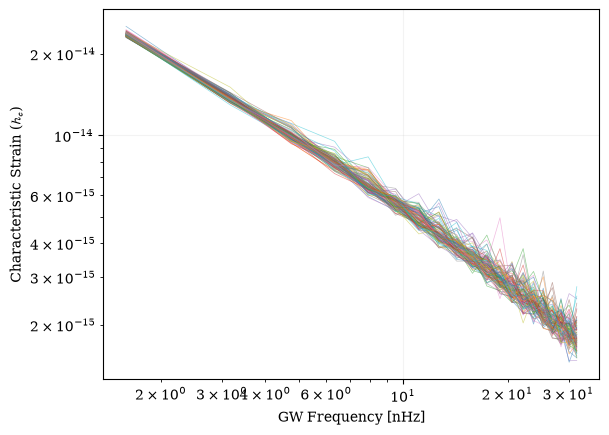

In [89]:
plt.loglog(fobs*1e9, hc_bg, lw=0.5, alpha=0.5);
plt.gca().set(ylabel='Characteristic Strain ($h_c$)', xlabel='GW Frequency [nHz]')
plt.show()

That's the core loop of `holodeck`: **population &rarr; GWB spectrum**, in two function calls.
Everything else in this notebook is either looking inside that black box, or changing what goes
into it.

A slightly fancier version of the same plot, now comparing the background to the loudest single
sources, and showing the reference $h_c(f) \propto f^{-2/3}$ power-law that a circular, GW-driven
binary population is expected to follow:

<>:1: SyntaxWarning: invalid escape sequence '\m'
<>:1: SyntaxWarning: invalid escape sequence '\m'
/var/folders/1b/rdn4sx6d387gkj77yypfp5nc0000gp/T/ipykernel_34615/3701310661.py:1: SyntaxWarning: invalid escape sequence '\m'
  fig, ax = plot.figax(xlabel='GW Frequency $f_\mathrm{obs}$ [1/yr]', ylabel='Characteristic Strain $h_c$')


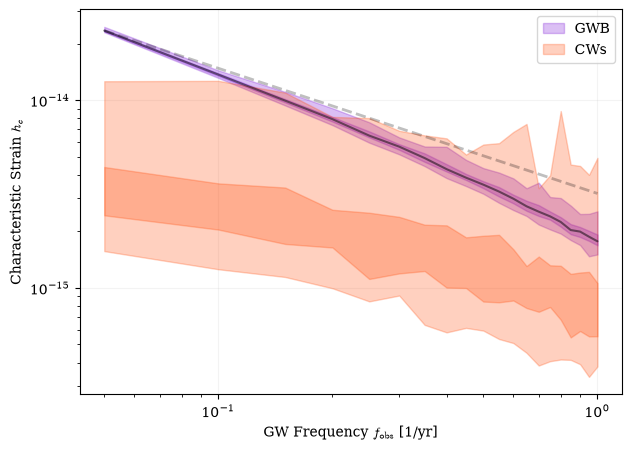

In [90]:
fig, ax = plot.figax(xlabel='GW Frequency $f_\mathrm{obs}$ [1/yr]', ylabel='Characteristic Strain $h_c$')

# `fobs` are bin centers in CGS units, convert to [1/yr]
xx = fobs * YR

# Get the median over all the realizations
med = np.median(hc_bg, axis=-1)

# plot a reference, pure power-law  strain spectrum:   h_c(f) = A * (f * yr) ^ -2/3
yy = med[0] * np.power(xx/xx[0], -2.0/3.0)
ax.plot(xx, yy, 'k--', alpha=0.25, lw=2.0)

# Plot the median GWB spectrum
ax.plot(xx, med, 'k-', alpha=0.5)

# Combine the `loudest` binaries in all realizations, to get distributions of their strains
singles = hc_ss.reshape((hc_ss.shape[0], -1))

# Plot distributions of GWB and Continuous Wave (CW) strains over all realizations
# contours at 50% and 98% confidence intervals
for pp in [50, 98]:
    percs = pp / 2
    percs = [50 - percs, 50 + percs]
    h1 = ax.fill_between(xx, *np.percentile(hc_bg, percs, axis=-1), alpha=0.25, color='#7100d4')
    h2 = ax.fill_between(xx, *np.percentile(singles, percs, axis=-1), alpha=0.25, color='orangered')

ax.legend([h1, h2], ['GWB', 'CWs'])
plt.show()

## Part 2 — Look under the hood: where does that spectrum come from?

`sam.gwb(...)` did a lot in one call. Let's build a SAM more explicitly and look at what's
actually inside it.

SAMs are built from simple analytic models to derive the number-density of MBH binaries. We start
with a **galaxy stellar-mass function (GSMF; $\psi$)**, giving the number of galaxies as a
function of stellar mass, and multiply by a **galaxy merger rate (GMR; $R$)** to get the rate of
galaxy-galaxy mergers:

$$\frac{\partial^3 n_{\star\star}(M_\star, q_\star, z)}{\partial \log_{10}(M_\star) \, \partial q_\star \, \partial z} = \psi(m_{1,\star}) \cdot R(M_\star, q_\star, z).$$

Here the total stellar mass of both galaxies is $M_\star \equiv m_{1,\star} + m_{2,\star}$, and
the stellar mass ratio is $q_\star \equiv m_{2,\star} / m_{1,\star}$.

To go from galaxy-galaxy mergers to MBH-MBH mergers, we apply an **M-Mbulge (MMB)** relation — the
MBH mass as a function of host stellar-bulge mass — giving the number density of MBH pairs, `n`,
as a function of MBH total mass `M`, MBH mass ratio `q`, and redshift `z`:

$$\frac{\partial^3 n(M, q, z)}{\partial \log_{10}(M) \, \partial q \, \partial z} = \psi(m_{1,\star}) \cdot R(M_\star, q_\star, z) \cdot \frac{\partial M_\star}{\partial M} \frac{\partial q_\star}{\partial q}.$$

The GMR itself is hard to measure directly, so we can do it one of two ways:

1. It's often approximated as a **galaxy pair-fraction
(GPF; $P$)** divided by a **galaxy merger time (GMT; $T$)**: $R \approx P / T$. That's the
parameterization we'll use below — it's the one holodeck *used to* default to.

2. We use a **galaxy merger rate (GMR; $R$)** based off of cosmological simulations (Illustris by default).


You must either specify (i) a GMR *or* (ii) both a GPF and a GMT, never all three.

The SAM is built on a 3-dimensional grid: total MBH mass (`M`), MBH mass ratio (`q`), and
redshift (`z`). Let's construct one explicitly, naming each physical component instead of using
all defaults:

In [91]:
# Specify the size of the SAM grid, with shape (M, Q, Z) for a grid of (total-mass, mass-ratio, redshift).
# We'll use a small grid so that calculations are fast (but not very accurate).
SAM_SHAPE = (30, 31, 32)

gsmf = holo.sams.GSMF_Schechter()                    # Galaxy Stellar-Mass Function (GSMF)
gpf = holo.sams.GPF_Power_Law()                      # Galaxy Pair Fraction         (GPF)
gmt = holo.sams.GMT_Power_Law()                      # Galaxy Merger Time           (GMT)
mmbulge = holo.host_relations.MMBulge_MM2013()       # M-MBulge Relation            (MMB)

sam = holo.sams.Semi_Analytic_Model(gsmf=gsmf, gpf=gpf, gmt=gmt, mmbulge=mmbulge, shape=SAM_SHAPE)

The number-density of MBH pairs is `sam.static_binary_density` — evaluated at the grid edges,
so its shape is one more than the number of bins in each dimension:

In [92]:
nden = sam.static_binary_density  # first access triggers the calculation, then it's cached
print(f"Shape of number density: {nden.shape}")
print(f"SAM `mtot` edges: [{sam.mtot[0]/MSOL:.1e}, {sam.mtot[-1]/MSOL:.1e}] Msol, with {sam.mtot.size} edges.")
print(f"SAM `mrat` edges: [{sam.mrat[0]:.1e}, {sam.mrat[-1]:.1e}], with {sam.mrat.size} edges.")
print(f"SAM `redz` edges: [{sam.redz[0]:.1e}, {sam.redz[-1]:.1e}], with {sam.redz.size} edges.")
print(f"SAM shape: {sam.shape}")

Shape of number density: (30, 31, 32)
SAM `mtot` edges: [1.0e+04, 1.0e+12] Msol, with 30 edges.
SAM `mrat` edges: [1.0e-03, 1.0e+00], with 31 edges.
SAM `redz` edges: [1.0e-03, 1.0e+01], with 32 edges.
SAM shape: (30, 31, 32)


A picture is worth a thousand printouts — number density in (mass, mass-ratio) space at one redshift slice:

<>:5: SyntaxWarning: invalid escape sequence '\o'
<>:5: SyntaxWarning: invalid escape sequence '\o'
/var/folders/1b/rdn4sx6d387gkj77yypfp5nc0000gp/T/ipykernel_34615/2837133236.py:5: SyntaxWarning: invalid escape sequence '\o'
  fig, ax = holo.plot.figax(xlabel='Total Mass $[M_\odot]$', ylabel='Mass Ratio')


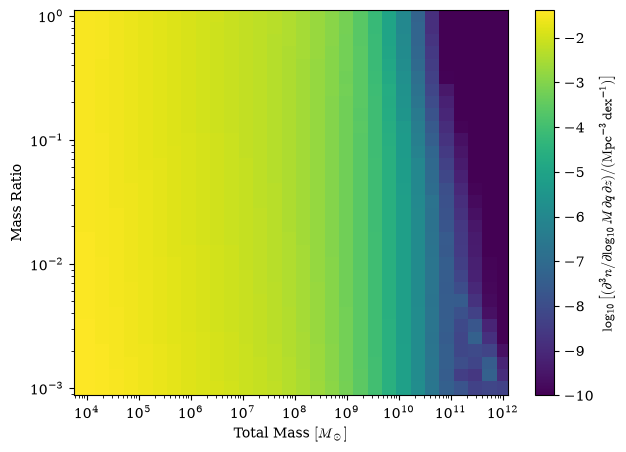

In [93]:
redz_indx = 15   # a redshift index roughly in the middle of the grid

nden_slice = sam.static_binary_density[:, :, redz_indx]

fig, ax = holo.plot.figax(xlabel='Total Mass $[M_\odot]$', ylabel='Mass Ratio')
pcm = ax.pcolormesh(sam.mtot / MSOL, sam.mrat, np.log10(nden_slice).T, vmin=-10)
label_units = (
    r'$\log_{10}\left['
    r'(\partial^3 n / \partial \log_{10} M \, \partial q \, \partial z)'
    r'/'
    r'(\mathrm{Mpc}^{-3} \, \mathrm{dex}^{-1})'
    r'\right]$'
)
plt.colorbar(pcm, ax=ax, label=label_units)
plt.show()

**Exercise A: change the SAM resolution.** Bump `SAM_SHAPE` up (e.g. `(40, 41, 42)`) or down
and re-run. Time it (`%%time` at the top of the cell works well) — this is the accuracy/speed
trade-off every holodeck run has to make. We won't re-plot this one; it's just to build intuition
for how grid size affects runtime before we change something physical in Exercise B.

In [94]:
%%time
# Exercise A — edit SAM_SHAPE and re-run this cell, then re-run the GWB + plot cells below.
SAM_SHAPE_ALT = (40, 41, 42)   # <-- change me

sam_alt1 = holo.sams.Semi_Analytic_Model(gsmf=gsmf, gpf=gpf, gmt=gmt, mmbulge=mmbulge, shape=SAM_SHAPE_ALT)
NUM_REALS = 100    # Number of 'realizations' to generate
NUM_LOUDEST = 2     # Number of 'loudest' binaries to generate in each frequency bin
hc_ss, hc_bg = sam_alt1.gwb(fobs_edges, realize=NUM_REALS, loudest=NUM_LOUDEST)

passed redz check at the beginning of ss_gws_redz()
CPU times: user 3.63 s, sys: 51.1 ms, total: 3.69 s
Wall time: 3.68 s


**Exercise B: change a physical assumption.** 

Try some of the following:

1. Try a different M-Mbulge normalization (`mamp_log10`, in log10 of solar masses; default is 8.17) or power-law slope (`mplaw`; default is
1.01) using `MMBulge_Standard` via `mmbulge_alt = MMBulge_Standard(mamp_log10=xx, mplay=yy)`, and compare the resulting spectrum against the default.  This is the same kind of parameter study that goes into holodeck's science papers, just at a much smaller
scale.

2. Instead of using a GPF and a GMT, use the default GMR (`gmr = holo.sams.GMR_Illustris()`).

3. Use a more modern galaxy stellar mass function (`gsmf=GSMF_Double_Schechter()`)

4. Try using an *evolving* M–Mbulge relation (`mmbulge_evol = MMBulge_Redshift(zplaw_amp=1.1)`)

In [101]:
# Exercise B — try changing these and re-running
gmr = holo.sams.GMR_Illustris()
# mmbulge_alt = holo.host_relations.MMBulge_Standard(mamp_log10=9.0)
# mmbulge_alt2 = holo.host_relations.MMBulge_Redshift(zplaw_amp=1.1)
#gsmf=holo.sams.GSMF_Double_Schechter()
gsmf = holo.sams.GSMF_Schechter()                    # Galaxy Stellar-Mass Function (GSMF)
sam_alt = holo.sams.Semi_Analytic_Model(gsmf=gsmf, gmr=gmr, mmbulge=mmbulge, shape=SAM_SHAPE)

Now compute and overlay the GWB spectra for the default SAM (`sam`) and your modified one (`sam_alt`):

<>:4: SyntaxWarning: invalid escape sequence '\m'
<>:4: SyntaxWarning: invalid escape sequence '\m'
/var/folders/1b/rdn4sx6d387gkj77yypfp5nc0000gp/T/ipykernel_34615/3295186712.py:4: SyntaxWarning: invalid escape sequence '\m'
  fig, ax = plot.figax(xlabel='GW Frequency $f_\mathrm{obs}$ [1/yr]', ylabel='Characteristic Strain $h_c$')


passed redz check at the beginning of ss_gws_redz()
15:31:00 ERROR : Warning, significant change in number-mass!  mass: 3.57e-01 ==> 5.97e-01 || change = 6.7204e-01 [sam.py:static_binary_density]
passed redz check at the beginning of ss_gws_redz()


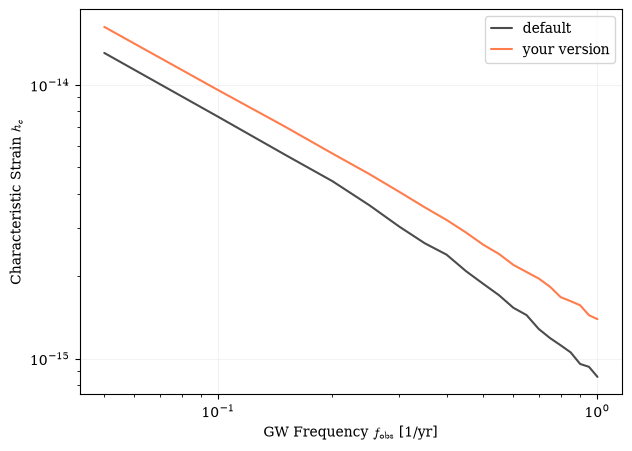

In [102]:
hc_ss_default, hc_bg_default = sam.gwb(fobs_edges, realize=NUM_REALS, loudest=NUM_LOUDEST)
hc_ss_alt, hc_bg_alt = sam_alt.gwb(fobs_edges, realize=NUM_REALS, loudest=NUM_LOUDEST)

fig, ax = plot.figax(xlabel='GW Frequency $f_\mathrm{obs}$ [1/yr]', ylabel='Characteristic Strain $h_c$')
xx = fobs * YR

ax.plot(xx, np.median(hc_bg_default, axis=-1), 'k-', alpha=0.7, label='default')
ax.plot(xx, np.median(hc_bg_alt, axis=-1), '-', color='orangered', alpha=0.7, label='your version')
ax.legend()
plt.show()

**If you have extra time:** try swapping in a different GSMF, GPF, or GMT class entirely
(e.g. `holo.sams.GSMF_Double_Schechter()`), or building the SAM from a Galaxy Merger Rate directly
instead of GPF/GMT — the commented-out block in the real `semi-analytic-models.ipynb` (linked at
the end of this notebook) shows how.

## Part 4 (optional / if time allows) — binary evolution ("hardening")

So far we've only used gravitational-wave-driven evolution to move binaries from galaxy-merger
separations down to where they emit in the PTA band. That's the simplest assumption. holodeck also
supports more realistic multi-phase hardening models (dynamical friction, stellar scattering, gas
torques, then GW emission). Here's a quick look at how the two compare — feel free to skip this
section during the live session and come back to it later.

In [97]:
# Frequency bins for this comparison
fobs_gw_edges = np.logspace(-1, 2, 31) / YR
fobs_gw_cents = holo.utils.midpoints(fobs_gw_edges, log=True)
fobs_orb_edges = fobs_gw_edges / 2.0
fobs_orb_cents = fobs_gw_cents / 2.0

# GW-only evolution
hard_gw = holo.hardening.Hard_GW()
_edges, diff_num_gw, redz_final = sam.dynamic_binary_number_at_fobs(hard_gw, fobs_orb_cents, use_cython=False)

# Phenomenological, multi-phase evolution over a fixed total binary lifetime
lifetime = 0.1e9 * YR  ## <-- try changing this
gamma_inner = -1.0 ## <-- try changing this
hard_ph = holo.hardening.Fixed_Time_2PL_SAM(sam, lifetime, sepa_init=1.0e4*PC, gamma_inner=gamma_inner)
_edges, diff_num_ph, redz_final = sam.dynamic_binary_number_at_fobs(hard_ph, fobs_orb_cents)

<>:4: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\o'
<>:4: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\o'
/var/folders/1b/rdn4sx6d387gkj77yypfp5nc0000gp/T/ipykernel_34615/3689098186.py:4: SyntaxWarning: invalid escape sequence '\l'
  units = 'Number [$d^4 N/ d\log_{10}\! M \, dq \, dz \, d\ln \! f$]'
/var/folders/1b/rdn4sx6d387gkj77yypfp5nc0000gp/T/ipykernel_34615/3689098186.py:6: SyntaxWarning: invalid escape sequence '\o'
  fig, ax = holo.plot.figax(xlabel='Total Mass [$M_\odot$]', ylabel=units, ylim=[1e-2, 1e12])


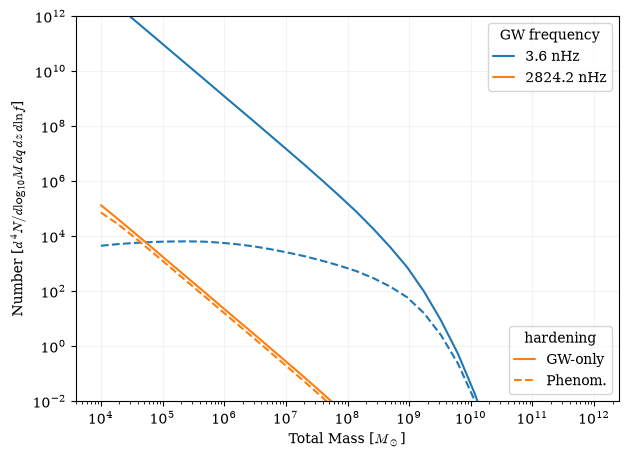

In [98]:
mrat_indx = -1
redz_indx = 15
fobs_indx = [0, -1]
units = 'Number [$d^4 N/ d\log_{10}\! M \, dq \, dz \, d\ln \! f$]'

fig, ax = holo.plot.figax(xlabel='Total Mass [$M_\odot$]', ylabel=units, ylim=[1e-2, 1e12])
for fidx in fobs_indx:
    fo = fobs_gw_cents[fidx]
    num_gw = diff_num_gw[:, mrat_indx, redz_indx, fidx]
    h1, = ax.plot(sam.mtot/MSOL, num_gw, label=f'{fo*1e9:.1f} nHz')
    num_ph = diff_num_ph[:, mrat_indx, redz_indx, fidx]
    h2, = ax.plot(sam.mtot/MSOL, num_ph, ls='--', color=h1.get_color())

leg = ax.legend(title='GW frequency', loc='upper right')
ax.legend([h1, h2], ['GW-only', 'Phenom.'], title='hardening', loc='lower right')
ax.add_artist(leg)
plt.show()

## Where to go from here

- Full demonstration notebooks (this one, plus discrete/Illustris populations, host-galaxy
  relations, single-source/continuous-wave calculations, and more):
  https://github.com/nanograv/holodeck/tree/dev/notebooks
- Getting Started guide: https://holodeck-gw.readthedocs.io/en/main/getting_started/index.html
- Full API docs: https://holodeck-gw.readthedocs.io/en/main/
- Questions during/after the school: ask in the VIPER Summer School Slack, or open a GitHub issue
  / discussion on the holodeck repo.

Thanks for going through this with us — go build some universes.